In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "setup.py").exists() and (candidate / "data").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Project root not found. Run this notebook from inside the repository.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.model_classes import SimpleTransformer
from utils.embedding_transformer_utils import (
    get_torch_device,
    load_simple_transformer_model,
    sample_dataframe,
    set_torch_seed,
)

print(f"Project root: {PROJECT_ROOT}")

INITIAL_FEATURES_PATH = PROJECT_ROOT / "data" / 'normal_features'
TRAIN_PATH = INITIAL_FEATURES_PATH / "train.parquet"
VAL_PATH = INITIAL_FEATURES_PATH / "val.parquet"
TEST_PATH = INITIAL_FEATURES_PATH / "test.parquet"

RANDOM_STATE = 42
DEVICE = get_torch_device()
print(f"Using device: {DEVICE}")
print(f"Initial features: {INITIAL_FEATURES_PATH}")


Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Using device: cuda
Initial features: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/data/normal_features


# Simple Transformer Model - on initial features

This notebook trains a lightweight Transformer on initial-based citation features. Instead of using textual embeddings, each scalar initial feature is treated as a token: the model learns feature embeddings, applies a Transformer encoder, and predicts whether a citation pair is valid.

The implementation follows the shared model interface used in the rest of the project:

- `BaseModel`: common contract for preprocessing, training, prediction, evaluation, and saving.

- `SimpleTransformer`: PyTorch wrapper for initial features. It scales numeric initial columns with `RobustScaler`, supports optional validation during training, exposes `predict` / `predict_proba`, and saves a reloadable checkpoint.


## 1. Load initial feature data


In [ ]:
df_train = pd.read_parquet(TRAIN_PATH)
df_val = pd.read_parquet(VAL_PATH)
df_test = pd.read_parquet(TEST_PATH)

ID_COLUMNS = ["article_id", "ref_id"]
df_train = df_train.drop(columns=ID_COLUMNS, errors="ignore")
df_val = df_val.drop(columns=ID_COLUMNS, errors="ignore")
df_test = df_test.drop(columns=ID_COLUMNS, errors="ignore")

NON_FEATURE_COLS = {
    "is_reference_valid",
    "article_id",
    "ref_id",
    "vector_text_article",
    "vector_text_ref",
    "split",
}
INITIAL_FEATURE_COLS = [
    col
    for col in df_train.drop(columns=list(NON_FEATURE_COLS), errors="ignore").select_dtypes(include=[np.number, "bool"]).columns
]

print("Split sizes:", {"train": len(df_train), "val": len(df_val), "test": len(df_test)})
print(f"Initial feature columns ({len(INITIAL_FEATURE_COLS)}):")
print(INITIAL_FEATURE_COLS)


Split sizes: {'train': 2162520, 'val': 391242, 'test': 396382}
Initial feature columns (55):
['year_article', 'n_citation_article', 'year_ref', 'n_keywords_article', 'n_keywords_ref', 'n_authors_article', 'n_authors_ref', 'lang_article_Other', 'lang_article_de', 'lang_article_en', 'lang_article_es', 'lang_article_fr', 'lang_article_pt', 'lang_ref_Other', 'lang_ref_de', 'lang_ref_en', 'lang_ref_es', 'lang_ref_fr', 'lang_ref_pt', 'doc_type_article_conference', 'doc_type_article_journal', 'doc_type_ref_conference', 'doc_type_ref_journal', 'keywords_article_hash_0', 'keywords_article_hash_1', 'keywords_article_hash_2', 'keywords_article_hash_3', 'keywords_article_hash_4', 'keywords_article_hash_5', 'keywords_article_hash_6', 'keywords_article_hash_7', 'keywords_article_hash_8', 'keywords_article_hash_9', 'keywords_article_hash_10', 'keywords_article_hash_11', 'keywords_article_hash_12', 'keywords_article_hash_13', 'keywords_article_hash_14', 'keywords_article_hash_15', 'keywords_ref_hash_0

In [5]:
set_torch_seed(RANDOM_STATE)

# Use None to train/evaluate on the full split. Set an integer for faster notebook experiments.
MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None
MAX_TEST_SAMPLES = None

TRAINING_PARAMS = {
    "epochs": 15,
    "batch_size": 512,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "patience": 5,
}

MODEL_PARAMS = {
    "num_features": len(INITIAL_FEATURE_COLS),
    "d_model": 64,
    "nhead": 8,
    "num_layers": 2,
    "dim_feedforward": 128,
    "dropout": 0.15,
}

df_train_model = sample_dataframe(df_train, MAX_TRAIN_SAMPLES, RANDOM_STATE)
df_val_model = sample_dataframe(df_val, MAX_VAL_SAMPLES, RANDOM_STATE)
df_test_model = sample_dataframe(df_test, MAX_TEST_SAMPLES, RANDOM_STATE)

print("Model split sizes:", {"train": len(df_train_model), "val": len(df_val_model), "test": len(df_test_model)})


Model split sizes: {'train': 2162520, 'val': 391242, 'test': 396382}


## 2. Train the SimpleTransformer


[SimpleTransformer_initial] Preprocessing 2162520 rows...


/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Label distribution:
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64
[SimpleTransformer_initial] Starting training...


epoch 1 train:   0%|          | 0/4224 [00:00<?, ?it/s]

predict:   0%|          | 0/765 [00:00<?, ?it/s]

...

epoch 6 train:   0%|          | 0/4224 [00:00<?, ?it/s]

predict:   0%|          | 0/765 [00:00<?, ?it/s]

{'epoch': 6, 'train_loss': 0.4706400047173156, 'val_f1_weighted': 0.35291880259302877}
Early stopping at epoch 6


predict:   0%|          | 0/4224 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0     0.8059    0.6313    0.7080   1081260
           1     0.6969    0.8479    0.7650   1081260

    accuracy                         0.7396   2162520
   macro avg     0.7514    0.7396    0.7365   2162520
weighted avg     0.7514    0.7396    0.7365   2162520



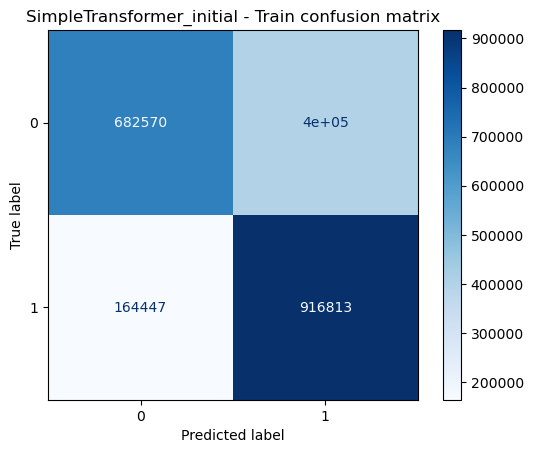

{'accuracy': 0.73959223498511,
 'f1_weighted': 0.7365005683408202,
 'precision_weighted': 0.7513906049969616,
 'recall_weighted': 0.73959223498511}

In [6]:
simple_transformer = SimpleTransformer(
    model_name="SimpleTransformer_initial",
    device=DEVICE,
    feature_cols=INITIAL_FEATURE_COLS,
    **MODEL_PARAMS,
)

train_metrics = simple_transformer.train_pipeline(
    df_train_model,
    raw_val=df_val_model,
    **TRAINING_PARAMS,
)
train_metrics


predict:   0%|          | 0/765 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0     0.5104    0.9794    0.6711    195621
           1     0.7464    0.0607    0.1123    195621

    accuracy                         0.5200    391242
   macro avg     0.6284    0.5200    0.3917    391242
weighted avg     0.6284    0.5200    0.3917    391242



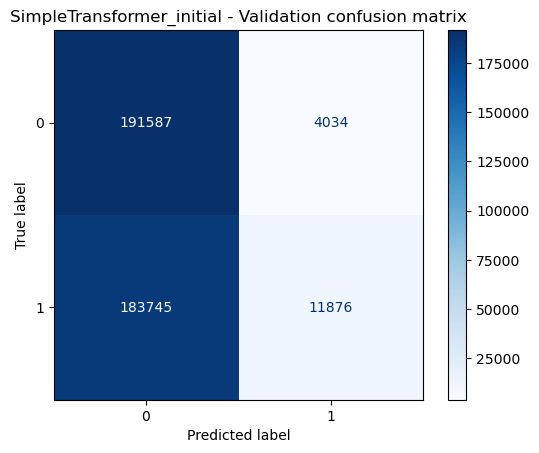

{'accuracy': 0.5200438603217445,
 'f1_weighted': 0.39169958813953,
 'precision_weighted': 0.6284477627493695,
 'recall_weighted': 0.5200438603217445}

In [7]:
X_val, y_val = simple_transformer.preprocess(df_val_model, is_training=False, verbose=False)
y_val_pred = simple_transformer.predict(X_val, batch_size=TRAINING_PARAMS["batch_size"])
validation_metrics = simple_transformer.evaluate(
    y_val,
    y_val_pred,
    title="SimpleTransformer_initial - Validation confusion matrix",
)
validation_metrics


## 3. Training notes

The validation split is passed directly to `train_pipeline`, so early stopping monitors weighted F1 on held-out data while keeping the scaler fitted only on the training split. The model can be trained on the full initial-feature dataset or on deterministic samples by changing the `MAX_*_SAMPLES` values above.


## 4. Optional hyperparameter experiments

`SimpleTransformer` is a PyTorch model, so the notebook uses a small manual experiment loop instead of `GridSearchCV`. Keep `RUN_HYPERPARAM_EXPERIMENTS = False` for a single final run, or enable it to compare a few compact configurations on the current train/validation samples.


In [8]:
RUN_HYPERPARAM_EXPERIMENTS = False

candidate_configs = [
    {"d_model": 32, "nhead": 4, "num_layers": 1, "dim_feedforward": 64, "dropout": 0.10},
    {"d_model": 64, "nhead": 4, "num_layers": 2, "dim_feedforward": 128, "dropout": 0.15},
    {"d_model": 128, "nhead": 8, "num_layers": 2, "dim_feedforward": 256, "dropout": 0.20},
]

experiment_results = []
best_model = None
best_score = -np.inf

if RUN_HYPERPARAM_EXPERIMENTS:
    for idx, config in enumerate(candidate_configs, start=1):
        set_torch_seed(RANDOM_STATE + idx)
        params = {"num_features": len(INITIAL_FEATURE_COLS), **config}
        candidate_model = SimpleTransformer(
            model_name=f"SimpleTransformer_initial_exp_{idx}",
            device=DEVICE,
            feature_cols=INITIAL_FEATURE_COLS,
            **params,
        )
        candidate_model.train_pipeline(df_train_model, raw_val=df_val_model, **TRAINING_PARAMS)

        X_val_exp, y_val_exp = candidate_model.preprocess(df_val_model, is_training=False, verbose=False)
        y_val_exp_pred = candidate_model.predict(X_val_exp, batch_size=TRAINING_PARAMS["batch_size"])
        metrics = candidate_model.evaluate(
            y_val_exp,
            y_val_exp_pred,
            title=f"SimpleTransformer_initial_exp_{idx} - Validation confusion matrix",
        )
        row = {"experiment": idx, **params, **metrics}
        experiment_results.append(row)

        if metrics["f1_weighted"] > best_score:
            best_score = metrics["f1_weighted"]
            best_model = candidate_model

    experiment_results = pd.DataFrame(experiment_results).sort_values("f1_weighted", ascending=False)
    display(experiment_results)
else:
    print("Set RUN_HYPERPARAM_EXPERIMENTS = True to run the comparison loop.")


Set RUN_HYPERPARAM_EXPERIMENTS = True to run the comparison loop.


## 5. Final evaluation on the test split

The final model is the best model from the optional experiment loop when that loop is enabled. Otherwise, it is the single `simple_transformer` trained above.


[SimpleTransformer_initial] Preprocessing 396382 rows...
Label distribution:
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64


predict:   0%|          | 0/775 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0     0.4995    0.9966    0.6655    198191
           1     0.3196    0.0016    0.0032    198191

    accuracy                         0.4991    396382
   macro avg     0.4096    0.4991    0.3343    396382
weighted avg     0.4096    0.4991    0.3343    396382



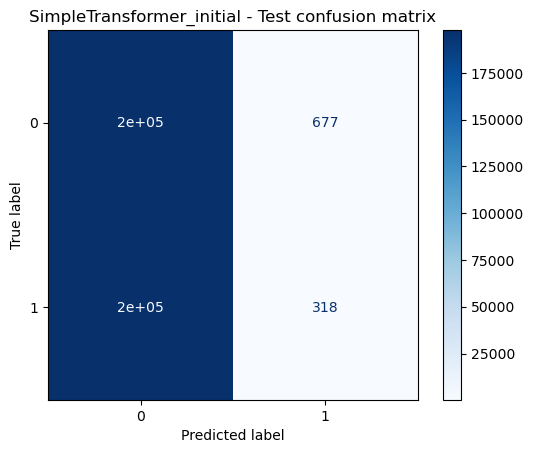

{'accuracy': 0.49909430801600474,
 'f1_weighted': 0.3343480485108471,
 'precision_weighted': 0.40957200218047296,
 'recall_weighted': 0.49909430801600474}

In [9]:
final_transformer = best_model if best_model is not None else simple_transformer

test_metrics = final_transformer.test_pipeline(
    df_test_model,
    batch_size=TRAINING_PARAMS["batch_size"],
)
test_metrics


## 6. Save and reload the trained model

The model is saved as a PyTorch checkpoint together with its scaler, selected feature columns, threshold, training history, and metadata summary. The reload helper restores the full wrapper so it can be used again with `preprocess`, `predict`, and `test_pipeline`.


In [10]:
from utils.model_saver import save_model_artifact
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'

save_model_artifact(final_transformer, df_name='initial_features', 
                    model_name="Transformer_initial_based", 
                    relative_model_dir=MODEL_SAVE_PATH)